In [1]:
# 1. Import libraries

# Used for working with dataframe/table data
import pandas as pd

# Used for numerical operations
import numpy as np

# Used for visualization/graphs
import matplotlib.pyplot as plt

# Used to save trained model
import pickle

# Split data into train and test sets
from sklearn.model_selection import train_test_split

# Linear Regression model
from sklearn.linear_model import LinearRegression

# Convert categorical data into numerical form
from sklearn.preprocessing import OneHotEncoder

# Apply transformations on selected columns
from sklearn.compose import ColumnTransformer

# Create ML pipeline
from sklearn.pipeline import Pipeline

# Used to check model accuracy
from sklearn.metrics import r2_score

In [2]:
car=pd.read_csv('quikr_car.csv')
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [3]:
car.shape

(892, 6)

In [4]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [5]:
car['year'].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [6]:
car['Price'].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [7]:
car['kms_driven'].unique

<bound method Series.unique of 0      45,000 kms
1          40 kms
2      22,000 kms
3      28,000 kms
4      36,000 kms
          ...    
887           NaN
888    27,000 kms
889    40,000 kms
890        Petrol
891        Petrol
Name: kms_driven, Length: 892, dtype: object>

In [8]:
car['fuel_type'].unique()

array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

In [9]:
car['name'].unique

<bound method Series.unique of 0        Hyundai Santro Xing XO eRLX Euro III
1                     Mahindra Jeep CL550 MDI
2                  Maruti Suzuki Alto 800 Vxi
3      Hyundai Grand i10 Magna 1.2 Kappa VTVT
4            Ford EcoSport Titanium 1.5L TDCi
                        ...                  
887                                        Ta
888                       Tata Zest XM Diesel
889                        Mahindra Quanto C8
890                  Honda Amaze 1.2 E i VTEC
891                 Chevrolet Sail 1.2 LT ABS
Name: name, Length: 892, dtype: object>

## Quality
- year has many non-year value
- year object to integer

- price has Ask for price
- Price obj to integer

- kms_driven ha kms with integer
- kms_driven object to integer
- kms_driven has nan values

- fuel_type has Nan value

- Name has lots of inconsistense
- name has neither categorical nor numerical
- convert into categorical --> keep First 3 words




## CLEANING

In [10]:
# Create backup copy of original dataset

backup=car.copy()

In [11]:
car['year']

0      2007
1      2006
2      2018
3      2014
4      2014
       ... 
887    zest
888    2018
889    2013
890    2014
891    2014
Name: year, Length: 892, dtype: object

In [12]:
# Keep only rows where year is numeric
car = car[car["year"].str.isnumeric()]
car



,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
886,Toyota Corolla Altis,Toyota,2009,"3,00,000","1,32,000 kms",Petrol
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN


In [13]:
# Convert year column into integer type
car["year"] = car["year"].astype(int)
car



,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
886,Toyota Corolla Altis,Toyota,2009,"3,00,000","1,32,000 kms",Petrol
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN


In [14]:
car['year'].unique()

array([2007, 2006, 2018, 2014, 2015, 2012, 2013, 2016, 2010, 2017, 2008,
       2011, 2019, 2009, 2005, 2000, 2003, 2004, 1995, 2002, 2001])

In [15]:
# Check dataset
car.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        842 non-null    object
 1   company     842 non-null    object
 2   year        842 non-null    int32 
 3   Price       842 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: int32(1), object(5)
memory usage: 42.8+ KB


## clean Price column

In [16]:

# Remove rows where price is "Ask For Price"
car = car[car["Price"] != "Ask For Price"]

In [17]:
car['Price'].unique()

array(['80,000', '4,25,000', '3,25,000', '5,75,000', '1,75,000',
       '1,90,000', '8,30,000', '2,50,000', '1,82,000', '3,15,000',
       '4,15,000', '3,20,000', '10,00,000', '5,00,000', '3,50,000',
       '1,60,000', '3,10,000', '75,000', '1,00,000', '2,90,000', '95,000',
       '1,80,000', '3,85,000', '1,05,000', '6,50,000', '6,89,999',
       '4,48,000', '5,49,000', '5,01,000', '4,89,999', '2,80,000',
       '3,49,999', '2,84,999', '3,45,000', '4,99,999', '2,35,000',
       '2,49,999', '14,75,000', '3,95,000', '2,20,000', '1,70,000',
       '85,000', '2,00,000', '5,70,000', '1,10,000', '4,48,999',
       '18,91,111', '1,59,500', '3,44,999', '4,49,999', '8,65,000',
       '6,99,000', '3,75,000', '2,24,999', '12,00,000', '1,95,000',
       '3,51,000', '2,40,000', '90,000', '1,55,000', '6,00,000',
       '1,89,500', '2,10,000', '3,90,000', '1,35,000', '16,00,000',
       '7,01,000', '2,65,000', '5,25,000', '3,72,000', '6,35,000',
       '5,50,000', '4,85,000', '3,29,500', '2,51,111', 

In [18]:
car['Price']

0        80,000
1      4,25,000
3      3,25,000
4      5,75,000
6      1,75,000
         ...   
886    3,00,000
888    2,60,000
889    3,90,000
890    1,80,000
891    1,60,000
Name: Price, Length: 819, dtype: object

In [19]:
# Remove commas from price values--> 
# remove with empty string and then convert whole string to integer
car["Price"] = car["Price"].str.replace(",", "")




C:\Users\AAQUIB\AppData\Local\Temp\ipykernel_12812\3683511677.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car["Price"] = car["Price"].str.replace(",", "")


In [20]:
car['Price']

0       80000
1      425000
3      325000
4      575000
6      175000
        ...  
886    300000
888    260000
889    390000
890    180000
891    160000
Name: Price, Length: 819, dtype: object

In [21]:
# Convert price column into integer type
car["Price"] = car["Price"].astype(int)

C:\Users\AAQUIB\AppData\Local\Temp\ipykernel_12812\1359502353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car["Price"] = car["Price"].astype(int)


In [22]:
# Check dataframe information
car.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int32 
 3   Price       819 non-null    int32 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int32(2), object(4)
memory usage: 38.4+ KB


## CLEAN KM_Driven

In [23]:
# we need to remove this comma and remove kms written
car['kms_driven']


0        45,000 kms
1            40 kms
3        28,000 kms
4        36,000 kms
6        41,000 kms
           ...     
886    1,32,000 kms
888      27,000 kms
889      40,000 kms
890          Petrol
891          Petrol
Name: kms_driven, Length: 819, dtype: object

In [24]:
# Remove rows having non-numeric kms values

car = car[
    car["kms_driven"] != "Petrol"
]


# Remove ' kms' text
# Example: 45,000 kms -> 45,000

car["kms_driven"] = car["kms_driven"].str.replace(" kms", "")


# Remove commas
# Example: 45,000 -> 45000

car["kms_driven"] = car["kms_driven"].str.replace(",", "")


# Convert into integer

car["kms_driven"] = car["kms_driven"].astype(int)


# Check result

car["kms_driven"].head()

0    45000
1       40
3    28000
4    36000
6    41000
Name: kms_driven, dtype: int32

In [25]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int32 
 3   Price       817 non-null    int32 
 4   kms_driven  817 non-null    int32 
 5   fuel_type   816 non-null    object
dtypes: int32(3), object(3)
memory usage: 35.1+ KB


In [26]:
car.head(15)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel
7,Hyundai Eon,Hyundai,2013,190000,25000,Petrol
8,Ford EcoSport Ambiente 1.5L TDCi,Ford,2016,830000,24530,Diesel
9,Maruti Suzuki Alto K10 VXi AMT,Maruti,2015,250000,60000,Petrol
10,Skoda Fabia Classic 1.2 MPI,Skoda,2010,182000,60000,Petrol
11,Maruti Suzuki Stingray VXi,Maruti,2015,315000,30000,Petrol



## clean Fuel_type



In [27]:

# Check fuel_type column

car["fuel_type"].unique()


array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

In [28]:
# give me value where fueltype is null
car[car['fuel_type'].isna()]

,name,company,year,Price,kms_driven,fuel_type
132,Toyota Corolla,Toyota,2009,275000,26000,NaN


In [29]:

# Remove rows where fuel_type is missing/null
car = car[car["fuel_type"].notnull()]


# Check dataset information
car.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int32 
 3   Price       816 non-null    int32 
 4   kms_driven  816 non-null    int32 
 5   fuel_type   816 non-null    object
dtypes: int32(3), object(3)
memory usage: 35.1+ KB


## clean the name

In [30]:
# Keep only first 3 words from car name
car["name"] = car["name"].str.split().str.slice(0, 3).str.join(" ")




In [31]:
# Check updated names

car["name"].head()

0       Hyundai Santro Xing
1       Mahindra Jeep CL550
3         Hyundai Grand i10
4    Ford EcoSport Titanium
6                 Ford Figo
Name: name, dtype: object

In [32]:
car['name']

0         Hyundai Santro Xing
1         Mahindra Jeep CL550
3           Hyundai Grand i10
4      Ford EcoSport Titanium
6                   Ford Figo
                ...          
883        Maruti Suzuki Ritz
885            Tata Indica V2
886      Toyota Corolla Altis
888              Tata Zest XM
889        Mahindra Quanto C8
Name: name, Length: 816, dtype: object

In [33]:
car=car.reset_index(drop=True)

In [34]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
812,Tata Indica V2,Tata,2009,110000,30000,Diesel
813,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [35]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int32 
 3   Price       816 non-null    int32 
 4   kms_driven  816 non-null    int32 
 5   fuel_type   816 non-null    object
dtypes: int32(3), object(3)
memory usage: 28.8+ KB


In [36]:
car.describe()

,year,Price,kms_driven
count,816.000000,8.160000e+02,816.000000
mean,2012.444853,4.117176e+05,46275.531863
std,4.002992,4.751844e+05,34297.428044
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.912500e+05,56818.500000
max,2019.000000,8.500003e+06,400000.000000


In [37]:
# Observations from numerical columns

# Total cleaned rows = 816

# Average car manufacturing year is around 2012

# Oldest car in dataset = 1995
# Newest car in dataset = 2019

# Average car price is around 4.1 lakh

# Minimum car price = 30,000
# Maximum car price = 85 lakh

# Average kilometers driven = 46,275 km

# Minimum kilometers driven = 0 km
# Maximum kilometers driven = 4,00,000 km

# Most cars are manufactured between 2010 to 2015

# Most cars are priced between 1.75 lakh to 4.9 lakh

# Most cars are driven around 27,000 km to 56,000 km

# 75% car are less tham 5 lakh and other cars are more than 5 lakh

In [38]:

# Show cars having price above 60 lakh
# this is outlier
car[car["Price"] > 6000000]

,name,company,year,Price,kms_driven,fuel_type
534,Mahindra XUV500 W6,Mahindra,2014,8500003,45000,Diesel


In [39]:
car[car["Price"] < 6000000]

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
812,Tata Indica V2,Tata,2009,110000,30000,Diesel
813,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [40]:
car=car[car["Price"] < 6000000].reset_index(drop=True)

In [41]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
810,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
811,Tata Indica V2,Tata,2009,110000,30000,Diesel
812,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
813,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [42]:
# Store cleaned dataset into new CSV file

car.to_csv(
    "cleaned_car_data.csv",
    index=False
)

## MODEL

In [52]:
# Remove price outliers
# Remove cars above 60 lakh

car = car[car["Price"] < 6000000]


# Remove kms_driven outliers
# Remove cars driven more than 2 lakh km

car = car[car["kms_driven"] < 200000]

In [62]:
# Create new feature: car age

car["car_age"] = 2026 - car["year"]

# Drop year column because car_age is more useful

car = car.drop("year", axis=1)

# Check data

car.head()

,name,company,Price,kms_driven,fuel_type,car_age
0,Hyundai Santro Xing,Hyundai,80000,45000,Petrol,19
1,Mahindra Jeep CL550,Mahindra,425000,40,Diesel,20
2,Hyundai Grand i10,Hyundai,325000,28000,Petrol,12
3,Ford EcoSport Titanium,Ford,575000,36000,Diesel,12
4,Ford Figo,Ford,175000,41000,Diesel,14


In [63]:
# Separate input features and target column

# X = independent/input features

X = car.drop(
    columns="Price"
)


# y = target/output column

y = car["Price"]

In [64]:
X

,name,company,kms_driven,fuel_type,car_age
0,Hyundai Santro Xing,Hyundai,45000,Petrol,19
1,Mahindra Jeep CL550,Mahindra,40,Diesel,20
2,Hyundai Grand i10,Hyundai,28000,Petrol,12
3,Ford EcoSport Titanium,Ford,36000,Diesel,12
4,Ford Figo,Ford,41000,Diesel,14
...,...,...,...,...,...
810,Maruti Suzuki Ritz,Maruti,50000,Petrol,15
811,Tata Indica V2,Tata,30000,Diesel,17
812,Toyota Corolla Altis,Toyota,132000,Petrol,17
813,Tata Zest XM,Tata,27000,Diesel,8


In [65]:
y

0       80000
1      425000
2      325000
3      575000
4      175000
        ...  
810    270000
811    110000
812    300000
813    260000
814    390000
Name: Price, Length: 811, dtype: int32

In [66]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% data for testing
    random_state=42     # ensures same random split every time
)

## MODEL

In [57]:
# Import regression models

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

In [58]:
# Create OneHotEncoder for categorical columns

ohe = OneHotEncoder(handle_unknown="ignore")

# Fit encoder on categorical columns
# These columns contain text, so machine cannot understand them directly

ohe.fit(X[["name", "company", "fuel_type"]])

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [59]:
# Create ColumnTransformer
# It will apply OneHotEncoding only on categorical columns
# Other numerical columns will pass as they are

column_trans = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(
                categories=ohe.categories_,
                handle_unknown="ignore"
            ),
            ["name", "company", "fuel_type"]
        )
    ],
    remainder="passthrough"
)

In [70]:
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "AdaBoost": AdaBoostRegressor(random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
}

In [71]:
# Train and test each model

for model_name, model in models.items():

    # Create pipeline
    pipe = Pipeline([
        ("preprocessing", column_trans),
        ("model", model)
    ])

    # Train model
    pipe.fit(X_train, y_train)

    # Predict test data
    y_pred = pipe.predict(X_test)

    # Check accuracy
    score = r2_score(y_test, y_pred)

    print(model_name)
    print("R2 Score:", score)
    print("-" * 40)

Linear Regression
R2 Score: 0.5978412401066071
----------------------------------------
Random Forest
R2 Score: 0.5935199699900255
----------------------------------------
Decision Tree
R2 Score: 0.5240957735644511
----------------------------------------
AdaBoost
R2 Score: 0.07235506045641116
----------------------------------------
XGBoost
R2 Score: 0.5852482914924622
----------------------------------------


In [72]:
# Final model

final_model = LinearRegression()

# Final pipeline

pipe = Pipeline([
    ("preprocessing", column_trans),
    ("model", final_model)
])

# Train final model

pipe.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [77]:
# Save trained model

with open("LinearRegressionModel.pkl", "wb") as file:
    pickle.dump(pipe, file)

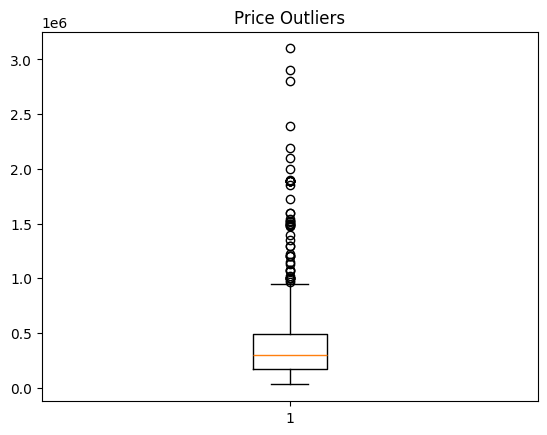

In [78]:
# Check outliers in Price column

plt.boxplot(car["Price"])

plt.title("Price Outliers")

plt.show()

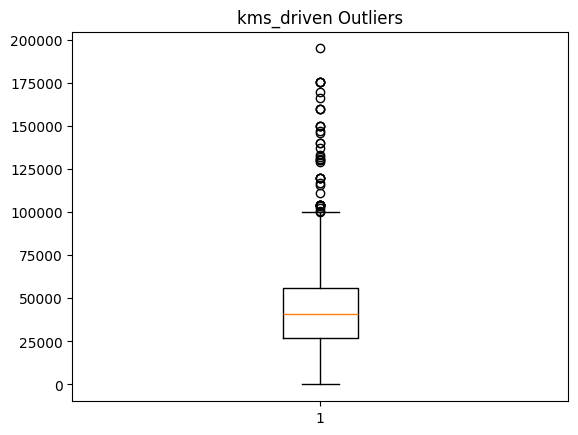

In [79]:
# Check outliers in kms_driven column

plt.boxplot(car["kms_driven"])

plt.title("kms_driven Outliers")

plt.show()

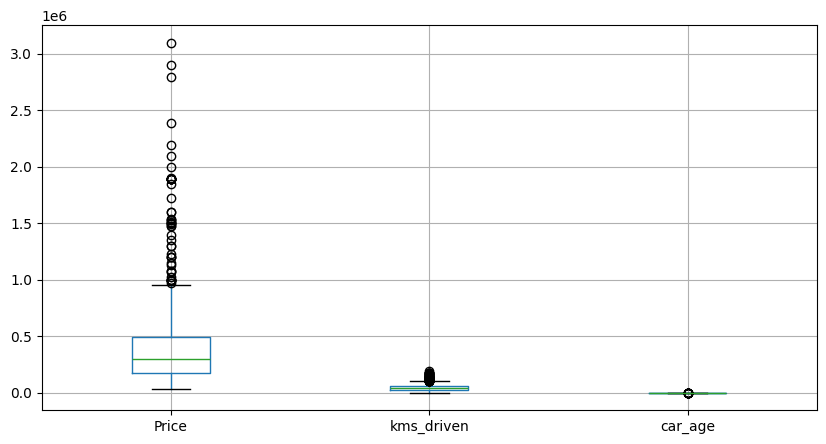

In [80]:
# Show boxplot for all numerical columns

car.boxplot(
    figsize=(10,5)
)

plt.show()